In [26]:
# AI generated:
# Learned and understood by creator.

from src.data_collection import get_trends_data
import matplotlib.pyplot as plt

## Results Analysis

In [27]:
data = get_trends_data()

## Google Trends Over Time
This section analyzes how public interest in each Resident Evil title changes over time using Google Trends data. It helps identify patterns in initial hype and how interest evolves after release.

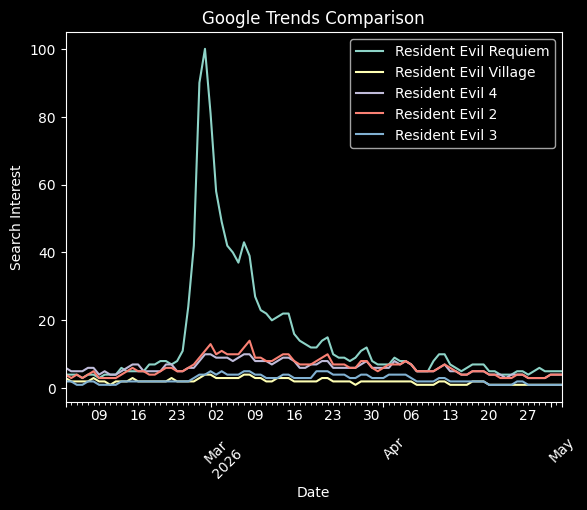

In [40]:
games = [col for col in data.columns if col != 'isPartial']

data[games].plot()
plt.title("Google Trends Comparison")
plt.xlabel("Date")
plt.ylabel("Search Interest")
plt.xticks(rotation=45)
plt.show()

## Peak and Early Interest Summary

In [50]:
data[games].describe().round(1)

,Resident Evil Requiem,Resident Evil Village,Resident Evil 4,Resident Evil 2,Resident Evil 3
count,90.0,90.0,90.0,90.0,90.0
mean,14.5,2.0,6.1,6.2,2.6
std,18.3,0.8,1.8,2.6,1.2
min,3.0,1.0,3.0,3.0,1.0
25%,5.0,1.0,5.0,4.0,2.0
50%,7.0,2.0,6.0,6.0,2.0
75%,13.8,2.0,7.0,8.0,4.0
max,100.0,4.0,10.0,14.0,5.0


In [30]:
peak_values = data[games].max()
avg_values = data[games].head(14).mean()

In [51]:
import pandas as pd

summary_df = pd.DataFrame({
    "Peak": peak_values,
    "Early Avg": avg_values
}) .round(1)

summary_df

,Peak,Early Avg
Resident Evil Requiem,100,4.2
Resident Evil Village,4,2.1
Resident Evil 4,10,5.4
Resident Evil 2,14,3.9
Resident Evil 3,5,1.6


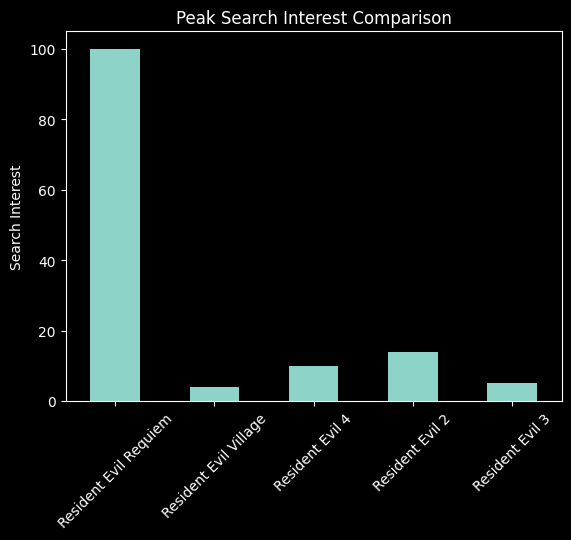

In [32]:
peak_values.plot(kind='bar')
plt.title("Peak Search Interest Comparison")
plt.ylabel("Search Interest")
plt.xticks(rotation=45)
plt.show()

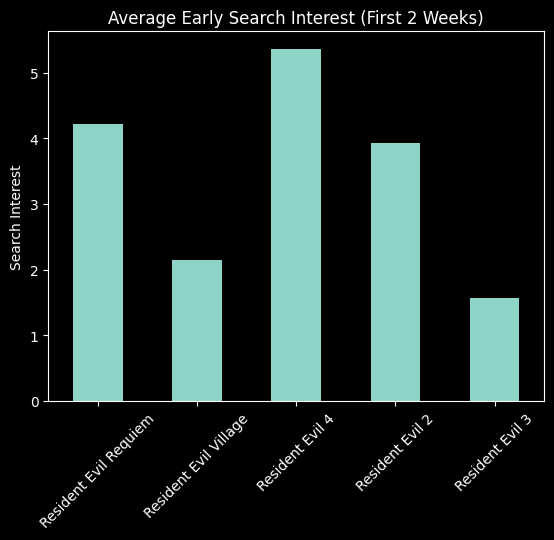

In [33]:
avg_values.plot(kind='bar')
plt.title("Average Early Search Interest (First 2 Weeks)")
plt.ylabel("Search Interest")
plt.xticks(rotation=45)
plt.show()

In [34]:
for game in games:
    peak_date = data[game].idxmax()
    peak_value = data[game].max()
    print(f"{game} peak: {peak_date}, {peak_value}")

Resident Evil Requiem peak: 2026-02-28 00:00:00, 100
Resident Evil Village peak: 2026-02-28 00:00:00, 4
Resident Evil 4 peak: 2026-02-28 00:00:00, 10
Resident Evil 2 peak: 2026-03-08 00:00:00, 14
Resident Evil 3 peak: 2026-03-01 00:00:00, 5


## Google Trends Summary
The results show that Resident Evil Requiem experiences a sharp spike in search interest at launch, indicating strong initial hype. However, interest declines quickly, while older titles maintain more stable and consistent search activity over time.

In [46]:
# AI Generated:

 ## Steam Data Analysis

This section analyzes player engagement and satisfaction using Steam data, including total reviews and positive review percentages across Resident Evil titles.

In [42]:
from src.data_collection import get_steam_app_details, get_steam_review_summary
from src.config import GAME_IDS

import pandas as pd
import matplotlib.pyplot as plt

# AI generated:
# Learned and understood by creator.

steam_rows = []

for game, app_id in GAME_IDS.items():
    details = get_steam_app_details(app_id)
    reviews = get_steam_review_summary(app_id)

    steam_rows.append({
        "Game": game,
        "Total_Reviews": reviews.get("total_reviews", 0),
        "Total_Positive": reviews.get("total_positive", 0),
        "Total_Negative": reviews.get("total_negative", 0),
    })

steam_df = pd.DataFrame(steam_rows)

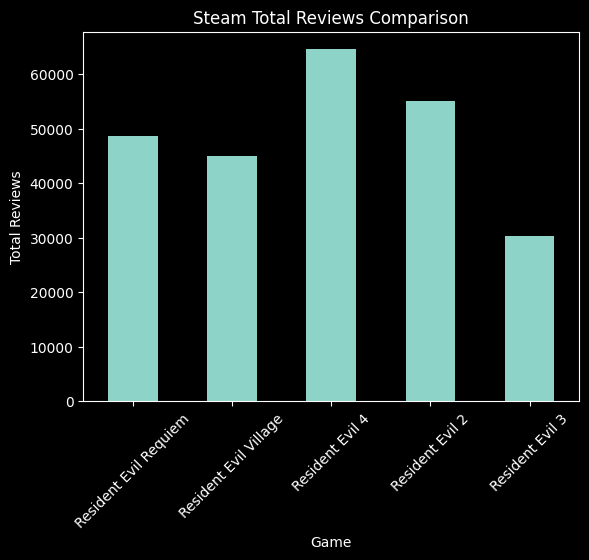

In [43]:
steam_df.set_index("Game")["Total_Reviews"].plot(kind="bar")
plt.title("Steam Total Reviews Comparison")
plt.ylabel("Total Reviews")
plt.xticks(rotation=45)
plt.show()

In [44]:
steam_df["Positive_Percentage"] = (
    steam_df["Total_Positive"] /
    (steam_df["Total_Positive"] + steam_df["Total_Negative"])
) * 100

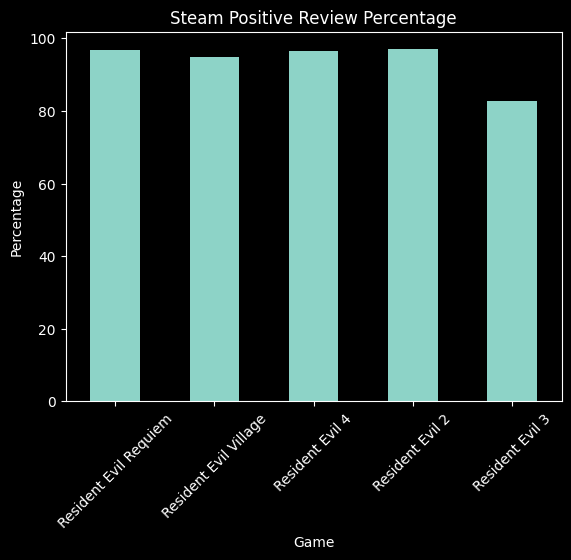

In [45]:
steam_df.set_index("Game")["Positive_Percentage"].plot(kind="bar")
plt.title("Steam Positive Review Percentage")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.show()

## Steam Summary
The results show that older titles have higher total review counts, reflecting stronger long-term engagement. However, all games maintain high positive review percentages, indicating consistently strong player satisfaction across the franchise.

## Final Conclusion
Overall, the analysis shows that Resident Evil Requiem generates the strongest initial public attention, but older titles demonstrate more consistent long-term engagement. This highlights that early hype does not always translate into sustained player activity, emphasizing the importance of analyzing both short-term and long-term performance using multiple data sources.